In [238]:
import os, sys, wave, struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import IPython

from copy import deepcopy
from math import ceil, exp, atan, pi, cos, sin
from scipy.io.wavfile import write
#import scipy.io.wavfile
from scipy.linalg import hankel
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

import pylab as p
#import matplotlib.axes3d as p3
import mpl_toolkits.mplot3d.axes3d as p3

# Useful functions

In [239]:
def load_sound(file):
    return wave.open(file, 'rb')

def plot_sound(data, times,xlim1,xlim2,name='default_name', save=False,w=20,h=10, lw = 3):
    plt.figure(figsize=(w, h))
    plt.plot(times,x.reshape(len_x))
    plt.xlim(xlim1,xlim2)
    plt.xlabel('time (s)')
    plt.ylabel('amplitude')
    if save:
        plt.savefig(name+'.png', dpi=100)
    plt.show()
    
def read_values(filename):
    wave_file = wave.open(filename, 'r')
    nframes = wave_file.getnframes()
    nchannels = wave_file.getnchannels()
    sampling_frequency = wave_file.getframerate()
    T = nframes / float(sampling_frequency)
    read_frames = wave_file.readframes(nframes)
    wave_file.close()
    data = struct.unpack("%dh" %  nchannels*nframes, read_frames)
    
    data_per_channel = [data[offset::nchannels] for offset in range(nchannels)]
    return T, np.array(data_per_channel), nframes, nchannels, sampling_frequency

In [240]:
def Synthesis(N,delta,f,a,phi,RSB=False):
    t = range(N)
    logz = delta + 1j*2*np.pi*f
    alpha = a*np.exp(1j*phi)
    x = np.sum(np.outer(alpha, np.ones(N))*np.exp(np.outer(logz,t)), axis=0)
    if RSB == False: 
        s = x
    else: 
        Ex = np.real(np.sum(np.abs(x)**2))/N
        b = np.random.normal(size=N) + 1j*np.random.normal(size=N)
        Eb = np.real(np.sum(np.abs(b)**2))/N
        b = b*np.sqrt(Ex/Eb)*10**(-RSB/20)
        s = x+b    
    return s

# Open audio file

In [241]:
wavefile = load_sound('ClocheB.WAV')
print(wavefile.getparams())

_wave_params(nchannels=1, sampwidth=2, framerate=8000, nframes=99414, comptype='NONE', compname='not compressed')


In [242]:
IPython.display.Audio('ClocheB.WAV')

In [243]:
T, data, nframes, nchannels, sampling_frequency = read_values('ClocheA.WAV')
Fs = int(wavefile.getframerate())
x = np.array(data)
num_samples = int(wavefile.getnframes())

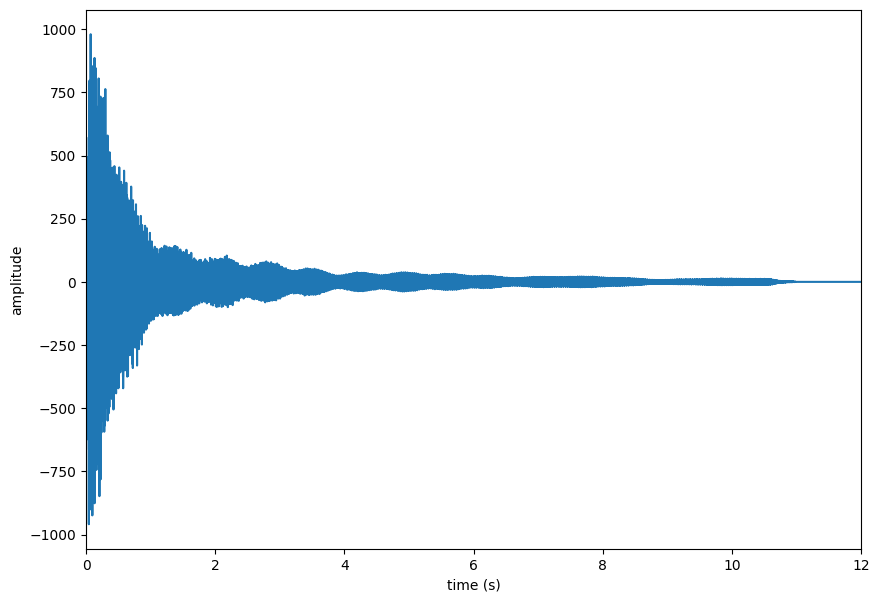

In [244]:
len_x = x.shape[1]
timestep = 1/(float(Fs))
times = np.arange(len_x)*timestep # int(len_x/6)
plot_sound(x.reshape(len_x), times,0,12,w=10,h=7)

In [245]:
write('new_bell.wav', Fs, np.array(x.reshape(len_x), dtype=np.int16)) # to write a new wave file

## 3. Synthetic signal

In [246]:
N=63
f = np.array([1/4, 1/4+1/N])
a = np.array([1,10])
delta = np.array([0, -0.05])
phi = np.random.uniform(-pi, pi, 2)
x = Synthesis(N, delta, f, a, phi)

### 3.1. Spectral analysis by Fourier transform

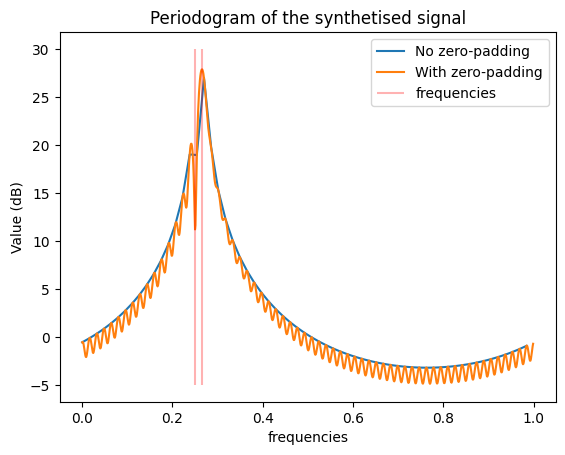

In [247]:
fft_X = np.fft.fft(x, n=N)
padded_fft_X = np.fft.fft(x, n=1024)

periodogram = (np.abs(fft_X)**2)/N
padded_periodogram = (np.abs(padded_fft_X)**2)/N
freq = np.arange(N) / N
padded_freq = np.arange(1024) / 1024

plt.plot(freq, 10*np.log10(periodogram), label="No zero-padding")
plt.plot(padded_freq, 10*np.log10(padded_periodogram), label="With zero-padding")
plt.vlines(f, -5, 30, colors="red", alpha=0.3, label="frequencies")
plt.title("Periodogram of the synthetised signal")
plt.legend()
plt.xlabel("frequencies")
plt.ylabel("Value (dB)")
plt.show()

The two spectral lines are too close to each other, making it impossible to separate both signals, they are both in the same big peak.

- Without padding : For the big peak, it is actually composed of two peaks : a smaller one and a bigger one, connected to each other. However the smaller peak isn't in the frequency $f_0$.

- With padding : The plot have multiple peaks, where the peaks coincides with the other plot's curve. For the two bigger peaks, it corresponds to $f_0$ and $f_0+\frac{1}{N}$ exactly. But they are not separable.

### 3.2. High resolution methods

In [248]:
n = 32
K = 2
l = N-n+1

1. Computation of the empirical covariance matrix

In [249]:
X = hankel(x[:n], x[n-1:])
emp_cov = (1/X.shape[1])*(X@X.conj().T)
print(X.shape[1]==l)

True


2. Estimation of the signal subspace

In [250]:
U1, lambd, U2 = np.linalg.svd(emp_cov)
W = U1[:,:K]
print(f"The signal subspace W {W.shape}:\n{W}")

The signal subspace W (32, 2):
[[-0.29352401+1.44416177e-17j -0.26516991+7.24927571e-17j]
 [ 0.03102015-2.76042291e-01j  0.00340603-2.40495368e-01j]
 [ 0.25655782+5.87250681e-02j  0.21681826+4.29286935e-03j]
 [-0.08310244+2.35491737e-01j -0.00288976+1.94323824e-01j]
 [-0.21324381-1.04180470e-01j -0.17316567+5.68767953e-04j]
 [ 0.12202374-1.90189746e-01j -0.00584621-1.53466992e-01j]
 [ 0.16667905+1.36728946e-01j  0.13532198-1.27070127e-02j]
 [-0.14842072+1.43033356e-01j  0.02091933+1.18797474e-01j]
 [-0.1195453 -1.57247486e-01j -0.10393479+3.02573802e-02j]
 [ 0.16337745-9.64777921e-02j -0.04050354-9.07516533e-02j]
 [ 0.07406376+1.66994700e-01j  0.07924421-5.14501534e-02j]
 [-0.16829557+5.25062218e-02j  0.06290104+6.93891592e-02j]
 [-0.03197875-1.67485085e-01j -0.06114586+7.46727310e-02j]
 [ 0.16477377-1.26262091e-02j -0.0865954 -5.44584824e-02j]
 [-0.00543423+1.60374583e-01j  0.04925808-9.85136126e-02j]
 [-0.15450021-2.21118209e-02j  0.11028677+4.54646761e-02j]
 [ 0.03734083-1.47360528e

### 3.2.1 ESPRIT method

3. Estimation of frequencies and damping factors

In [251]:
def ESPRIT_method(W):
    W_down = W[:-1,:]
    W_up = W[1:, :]

    Phi = np.linalg.pinv(W_down) @ W_up
    eigenvalues = np.linalg.eig(Phi)[0]
    print("ESPRIT method ---------------------")
    print(f"The {eigenvalues.shape} eigenvalues are : {eigenvalues}")
    deltas = np.log(np.abs(eigenvalues))
    fs = (1/(2*pi))*np.angle(eigenvalues)

    print(f"The {deltas.shape} deltas are : {deltas}")
    print(f"The {fs.shape} frequencies are : {fs}")
    return deltas, fs

4. Estimation of amplitudes and phases

In [252]:
def LeastSquares(x, delta, f):
    poles = np.exp(delta + 2*1j*pi*f)
    print("Least Squares ---------------------")
    print(f"The {poles.shape} poles z_k are : {poles}")

    t = np.arange(N).reshape(-1,1)
    print(t.shape)
    part=(delta + 2 * 1j * np.pi * f).reshape(1, -1)
    V = np.exp(t @ part)

    alpha = np.linalg.pinv(V) @ x
    print(f"The solution of the equation is alpha={alpha}")

    amplitudes = np.abs(alpha)
    phases = np.angle(alpha)
    print(f"The amplitudes are {amplitudes}")
    print(f"The phases are {phases}")
    return amplitudes, phases

deltas, fs = ESPRIT_method(W)
amplitudes, phases = LeastSquares(x, deltas, fs)

ESPRIT method ---------------------
The (2,) eigenvalues are : [-9.47118654e-02+0.94650255j -3.90312782e-17+1.j        ]
The (2,) deltas are : [-5.0000000e-02 -4.4408921e-16]
The (2,) frequencies are : [0.26587302 0.25      ]
Least Squares ---------------------
The (2,) poles z_k are : [-9.47118654e-02+0.94650255j  6.12323400e-17+1.j        ]
(63, 1)
The solution of the equation is alpha=[-3.27075818-9.449981j   -0.79331041+0.60881737j]
The amplitudes are [10.  1.]
The phases are [-1.90400386  2.48702366]


In [253]:
print(f"delta: Real {delta} vs Estimated {deltas}")
print(f"frequency: Real {f} vs Estimated {fs}")
print(f"amplitude: Real {a} vs Estimated {amplitudes}")
print(f"phase: Real {phi} vs Estimated {phases}")

delta: Real [ 0.   -0.05] vs Estimated [-5.0000000e-02 -4.4408921e-16]
frequency: Real [0.25       0.26587302] vs Estimated [0.26587302 0.25      ]
amplitude: Real [ 1 10] vs Estimated [10.  1.]
phase: Real [ 2.48702366 -1.90400386] vs Estimated [-1.90400386  2.48702366]


**COMMENTS:** 

The estimated parameters are almost the same as the real one, except that the order is inversed and that $0$ is estimated as a very small number : $-6.66 \times 10^{-16}$ due to the error of computing.


### 3.2.2 MUSIC method

6. MUSIC pseudo-spectrum

(32, 30)


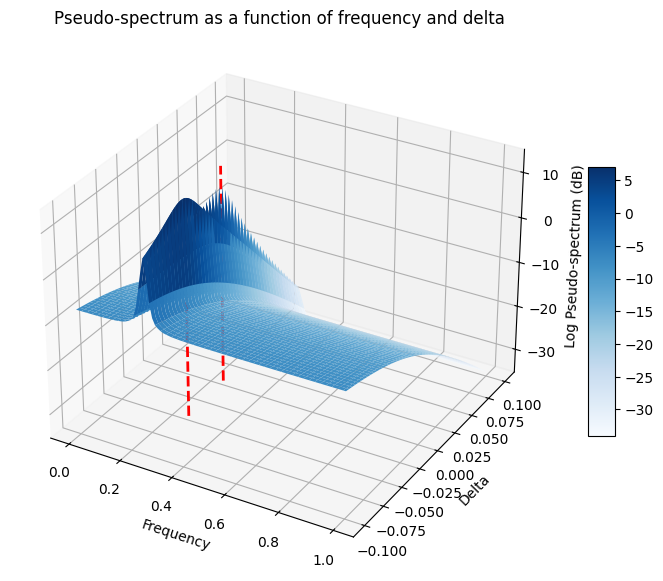

In [254]:
def MUSIC(x,n,K):
    X = hankel(x[:n], x[n-1:])
    emp_cov = (1/X.shape[1])*(X@X.conj().T)
    U1, lambd, U2 = np.linalg.svd(emp_cov)
    W_perp = U1[:,K:]
    print(W_perp.shape)

    freqs = np.linspace(0,1,100)
    delts = np.linspace(-0.1,0.1, 100)
    F, D = np.meshgrid(freqs, delts)

    def vandermoond(freq, delt):
        zs = np.exp(delt+ 2*1j*pi*freq)
        return np.array([zs**t for t in range(n)])
    
    P = np.zeros_like(F)
    for i in range(len(F)):
        for j in range(len(F[0])):
            freq = F[i,j]; delt = D[i,j]
            v=vandermoond(freq, delt)
            P[i,j]=1/(np.linalg.norm(W_perp.conj().T @ v))**2
    
    log_P = 10*np.log10(P)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,7))
    surf = ax.plot_surface(F, D, log_P, cmap=cm.Blues, edgecolor='none')
    ax.plot([1/4, 1/4], [0, 0], [log_P.min(), log_P.max()],color='red', 
            linewidth=2, 
            linestyle='--', 
        )
    ax.plot([1/4+1/N, 1/4+1/N], [-0.05, -0.05], [log_P.min(), log_P.max()],color='red', 
            linewidth=2, 
            linestyle='--', 
        )
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Delta")
    ax.set_zlabel("Log Pseudo-spectrum (dB)")
    ax.set_title("Pseudo-spectrum as a function of frequency and delta")

MUSIC(x,n,K)

We clearly see that the two peaks are exactly on the two poles for $(f,\delta)=(\frac{1}{4}, 0)$ and $(f,\delta)=(\frac{1}{4}+\frac{1}{N}, -0.05)$

## 4. Audio signals

### 4.1 Spectral analysis by Fourier transform

95997


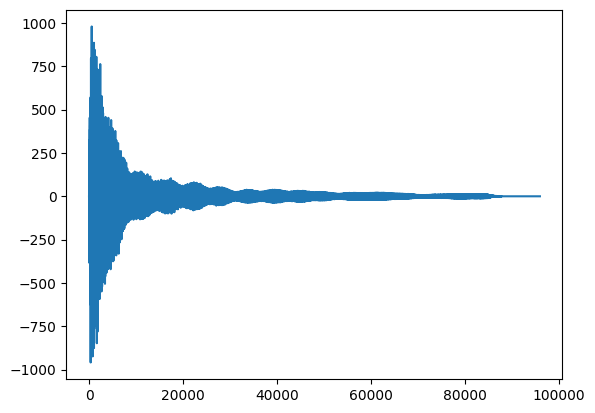

In [255]:
T, data, nframes, nchannels, sampling_frequency = read_values('ClocheA.WAV')
x = np.array(data).flatten()
num_samples = int(wavefile.getnframes())

fft_X = np.fft.fft(x, n=num_samples)
padded_fft_X = np.fft.fft(x, n=1024)

periodogram = ((np.abs(fft_X)**2)/num_samples)
padded_periodogram = ((np.abs(padded_fft_X)**2)/num_samples)
freq = Fs*np.arange(num_samples) / num_samples
padded_freq = Fs*np.arange(1024) / 1024

plt.plot(x)
print(len(x))

454.5838614279679
8000
8000
[    0     1     2 ... 99411 99412 99413]


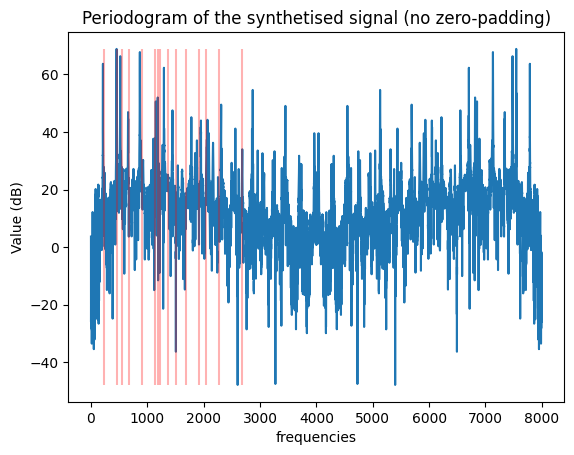

In [256]:
f_p = freq[5649]
print(f_p)
eigen_freqs = f_p*np.array([0.5, 1, 1.2, 1.5, 2, 2.5, 2.6, 2.7, 3, 3.3,3.7, 4.2, 4.5, 5, 5.9])
print(Fs)
print(sampling_frequency)
log_periodogram = 10*np.log10(periodogram)
plt.plot(freq, log_periodogram)
print(np.where(log_periodogram)[0])
plt.title("Periodogram of the synthetised signal (no zero-padding)")
plt.xlabel("frequencies")
plt.ylabel("Value (dB)")
plt.vlines(eigen_freqs, log_periodogram.min(), log_periodogram.max(), colors="red", alpha=0.3)
plt.show()

It perfectly aligns with the peaks of the periodogram, meaning that the eigenfrequencies are correct.

### 4.2 High frequency method

In [257]:
n=512
K= 54
l=2*n
N = n+l-1
print(N)

1535


In [258]:
start=10000
print(len(x))
x_trunc = x[start:start+N]
print(x_trunc.shape)
X = hankel(x_trunc[:n], x_trunc[n-1:])
print(X.shape)
emp_cov = (1/X.shape[1])*(X@X.conj().T)
U1, lambd, U2 = np.linalg.svd(emp_cov)
W = U1[:,:K]
print(f"The signal subspace W {W.shape}:\n{W}")
deltas, fs=ESPRIT_method(W)
amplitudes, phases=LeastSquares(x_trunc, deltas, fs)

95997
(1535,)
(512, 1024)


The signal subspace W (512, 54):
[[-0.05963264 -0.00067951  0.04298046 ...  0.0296748  -0.01387627
   0.07530654]
 [-0.0559875  -0.02145278  0.05738803 ...  0.05242821  0.07619069
  -0.00330305]
 [-0.04523313 -0.03957701  0.06219182 ... -0.02455141 -0.00953958
  -0.0852112 ]
 ...
 [-0.06147442  0.01846514  0.05660829 ... -0.01983801  0.05476304
   0.02609573]
 [-0.06415576 -0.00409737  0.05705844 ...  0.05467968  0.02392535
  -0.0493687 ]
 [-0.05868059 -0.02609713  0.04804015 ...  0.02643472 -0.05261205
  -0.01417756]]
ESPRIT method ---------------------
The (54,) eigenvalues are : [-0.90798457+0.41881482j -0.90798457-0.41881482j -0.88506109+0.4636658j
 -0.88506109-0.4636658j  -0.83398805+0.55103263j -0.83398805-0.55103263j
 -0.63149268+0.7751259j  -0.63149268-0.7751259j  -0.62308379+0.78132651j
 -0.62308379-0.78132651j -0.42689868+0.90377492j -0.42689868-0.90377492j
 -0.24128283+0.97013599j -0.24128283-0.97013599j -0.07987796+0.99228362j
 -0.07987796-0.99228362j  0.03941215+0.99884307

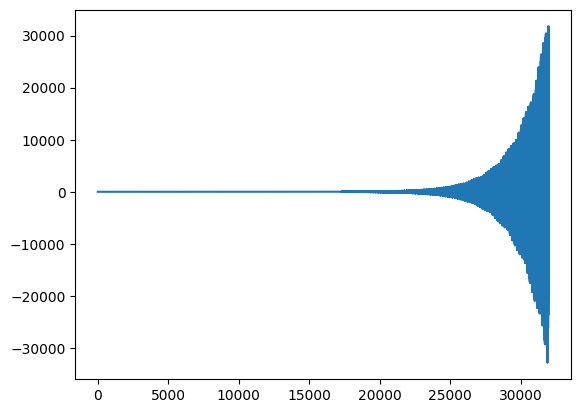

In [261]:
duration_seconds = 4
N = int(duration_seconds * sampling_frequency)
x_synth=Synthesis(N, deltas, fs, amplitudes, phases)
x_synth_real = np.real(x_synth)
x_synth_norm = np.int16((x_synth_real / np.max(np.abs(x_synth_real))) * 32767)
plt.plot(x_synth_norm)
write('synth_bell.wav', int(sampling_frequency), x_synth_norm)